In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [19]:
demographics = pd.read_csv("IDN_ADM2_demographics.csv")

In [20]:
evacuability = pd.read_csv("IDN_ADM2_evacuability.csv")

In [21]:
flood_exposure = pd.read_csv("IDN_ADM2_flood_exposure.csv")

In [22]:
rural_pop = pd.read_csv("IDN_ADM2_rural_population.csv")

In [23]:
file_path = "/Users/laneerwin/Documents/geog592-dev/geog592-cheyney/homework/week07/idn_admin2.shp"

In [24]:
boundaries = gpd.read_file(file_path)

In [25]:
# having trouble reading the shapefile, so let's check if the file exists
import os

print(os.getcwd())

/Users/laneerwin/Documents/geog592-dev/geog592-cheyney/homework/week07


In [26]:
print(os.path.exists(file_path))

# file path does exist and is correct, but needed the entire shapefile set, cpg, dbf, prj, shx, not just the shp file

True


In [27]:
print(boundaries.columns)

Index(['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode',
       'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',
       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',
       'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1',
       'lang2', 'lang3', 'adm2_ref_n', 'center_lat', 'center_lon', 'geometry'],
      dtype='str')


In [28]:
print(boundaries.head())

         adm2_name adm2_name1 adm2_name2 adm2_name3 adm2_pcode adm1_name  \
0       Aceh Barat       None       None       None     ID1107      Aceh   
1  Aceh Barat Daya       None       None       None     ID1112      Aceh   
2       Aceh Besar       None       None       None     ID1108      Aceh   
3        Aceh Jaya       None       None       None     ID1116      Aceh   
4     Aceh Selatan       None       None       None     ID1103      Aceh   

  adm1_name1 adm1_name2 adm1_name3 adm1_pcode  ...    area_sqkm version lang  \
0       None       None       None       ID11  ...  2810.080347     v01   en   
1       None       None       None       ID11  ...  1893.153439     v01   en   
2       None       None       None       ID11  ...  2897.326655     v01   en   
3       None       None       None       ID11  ...  3878.163240     v01   en   
4       None       None       None       ID11  ...  4216.151500     v01   en   

  lang1 lang2 lang3       adm2_ref_n  center_lat center_lon  \

In [29]:
print(demographics.head())

  ADM2_PCODE ADM_PCODE  total_pop  female_pop  children_u5  female_u5  \
0     ID1107    ID1107     213662      106104        16205       7856   
1     ID1112    ID1112     163453       81189        12602       6127   
2     ID1108    ID1108     426779      212687        36893      17894   
3     ID1116    ID1116      94733       46817         8331       4069   
4     ID1103    ID1103     241711      121692        17188       8334   

   elderly  pop_u15  female_u15  wra_pop  dependency_ratio  
0    16220    50985       24885    55394             45.89  
1    11461    37922       18348    43567             43.29  
2    31718   114045       55471   108374             51.87  
3     7032    25817       12688    23993             53.08  
4    20238    52841       25651    63214             43.34  


In [30]:
# this is creating my first layer with a join.
demographic_boundaries = boundaries.merge(
    demographics,
    left_on = "adm2_pcode",
    right_on = "ADM2_PCODE",
    how = "left")

In [31]:
print(demographic_boundaries.head())

         adm2_name adm2_name1 adm2_name2 adm2_name3 adm2_pcode adm1_name  \
0       Aceh Barat       None       None       None     ID1107      Aceh   
1  Aceh Barat Daya       None       None       None     ID1112      Aceh   
2       Aceh Besar       None       None       None     ID1108      Aceh   
3        Aceh Jaya       None       None       None     ID1116      Aceh   
4     Aceh Selatan       None       None       None     ID1103      Aceh   

  adm1_name1 adm1_name2 adm1_name3 adm1_pcode  ... ADM_PCODE total_pop  \
0       None       None       None       ID11  ...    ID1107    213662   
1       None       None       None       ID11  ...    ID1112    163453   
2       None       None       None       ID11  ...    ID1108    426779   
3       None       None       None       ID11  ...    ID1116     94733   
4       None       None       None       ID11  ...    ID1103    241711   

  female_pop children_u5 female_u5 elderly pop_u15  female_u15 wra_pop  \
0     106104       16205

In [32]:
print(demographic_boundaries["ADM2_PCODE"].isna().sum())

0


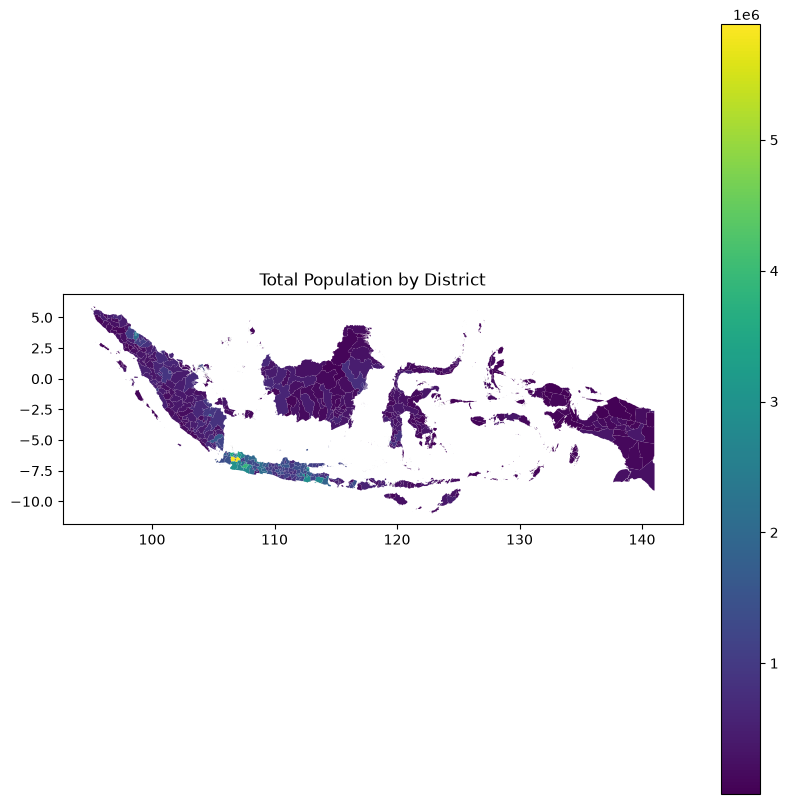

In [33]:
demographic_boundaries.plot(
    column = "total_pop",
    legend = True,
    figsize = (10, 10)
)

plt.title("Total Population by District")
plt.show()

In [43]:
high_population = demographic_boundaries[
    demographic_boundaries["total_pop"] >= 
    demographic_boundaries["total_pop"].quantile(0.75)
].copy()

In [44]:
print(len(high_population))

131


In [45]:
print(boundaries.crs)

EPSG:4326


In [ ]:
# need to reproject because i want to eventually create a buffer
projected_high_population = high_population.to_crs(epsg=3857)

In [47]:
population_buffer = high_population.copy()

In [ ]:
# DONT THINK I NEED THIS
# demographic_boundaries.to_file(
#     "IDN_ADM2_demographics_joined.shp"
# )